In [8]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

TICKER = "XOM"
PEERS = ["CVX", "COP", "OXY", "BP", "SHEL"]

forecast_years = 5
terminal_growth = 0.025
tax_rate = 0.21
wacc_base = 0.09

# sensitivity assumptions for Exxon vs oil price
base_oil_price = 75
revenue_sensitivity_per_10 = 0.04      # revenue changes 4% for each $10 move in oil
ebit_margin_sensitivity_per_10 = 0.01  # margin changes 1 percentage point for each $10 move in oil

# fallback assumptions if Yahoo fields are missing
fallback_ebit_margin = 0.10
fallback_depr_pct = 0.05
fallback_capex_pct = 0.07
fallback_nwc_pct = 0.01
fallback_net_debt = 20000  # in millions
fallback_shares = 4200     # in millions



# Functions of models

In [ ]:
# ============================================================
# HELPERS
# ============================================================

def safe_get(d, keys, default=None):
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default


def first_valid(df, row_names):
    """
    Find first matching row in a yfinance statement DataFrame.
    Returns the most recent non-null value.
    """
    if df is None or df.empty:
        return None

    for row in row_names:
        if row in df.index:
            s = df.loc[row].dropna()
            if not s.empty:
                return float(s.iloc[0])
    return None


def to_millions(x):
    if x is None:
        return None
    return x / 1_000_000



def clean_positive(x, fallback):
    if x is None or pd.isna(x):
        return fallback
    return x


def adjust_for_oil_price(oil_price, revenue, ebit_margin):
    oil_diff = oil_price - base_oil_price
    step = oil_diff / 10.0
    adj_revenue = revenue * (1 + revenue_sensitivity_per_10 * step)
    adj_margin = ebit_margin + ebit_margin_sensitivity_per_10 * step
    return adj_revenue, adj_margin


def project_fcf(revenue, ebit_margin, depr_pct, capex_pct, nwc_pct, years=5):
    growth_rates = [0.03, 0.03, 0.025, 0.02, 0.02]

    rows = []
    rev = revenue

    for year in range(1, years + 1):
        growth = growth_rates[year - 1]
        rev *= (1 + growth)

        ebit = rev * ebit_margin
        nopat = ebit * (1 - tax_rate)
        depreciation = rev * depr_pct
        capex = rev * capex_pct
        nwc_change = rev * nwc_pct
        fcf = nopat + depreciation - capex - nwc_change

        rows.append({
            "Year": year,
            "Revenue": rev,
            "EBIT": ebit,
            "NOPAT": nopat,
            "Depreciation": depreciation,
            "Capex": capex,
            "Change_in_NWC": nwc_change,
            "FCF": fcf,
        })

    return pd.DataFrame(rows)


def dcf_valuation(fcf_df, wacc, terminal_growth, net_debt, shares_outstanding):
    fcf_df = fcf_df.copy()
    fcf_df["Discount_Factor"] = 1 / ((1 + wacc) ** fcf_df["Year"])
    fcf_df["PV_FCF"] = fcf_df["FCF"] * fcf_df["Discount_Factor"]

    terminal_fcf = fcf_df.iloc[-1]["FCF"] * (1 + terminal_growth)
    terminal_value = terminal_fcf / (wacc - terminal_growth)
    pv_terminal = terminal_value / ((1 + wacc) ** fcf_df.iloc[-1]["Year"])

    enterprise_value = fcf_df["PV_FCF"].sum() + pv_terminal
    equity_value = enterprise_value - net_debt
    implied_share_price = equity_value / shares_outstanding

    return fcf_df, {
        "Enterprise Value (mm)": enterprise_value,
        "Equity Value (mm)": equity_value,
        "Implied Value per Share": implied_share_price,
        "PV Terminal Value (mm)": pv_terminal,
    }


def comp_valuation(company_ebitda, peer_multiples, net_debt, shares_outstanding):
    avg_multiple = np.mean(peer_multiples)
    ev = company_ebitda * avg_multiple
    eq = ev - net_debt
    value_per_share = eq / shares_outstanding
    return {
        "Average Peer EV/EBITDA": avg_multiple,
        "Enterprise Value (mm)": ev,
        "Equity Value (mm)": eq,
        "Implied Value per Share": value_per_share
    }


def get_peer_ev_ebitda(ticker_symbol):
    t = yf.Ticker(ticker_symbol)
    info = t.info

    ev = safe_get(info, ["enterpriseValue"])
    ebitda = safe_get(info, ["ebitda"])

    if ev is None or ebitda is None or ebitda == 0:
        return None

    return ev / ebitda


# ============================================================


# Downloading the Data 

In [11]:
# DOWNLOAD XOM DATA
# ============================================================

xom = yf.Ticker(TICKER)
info = xom.info

income_stmt = xom.income_stmt
cashflow = xom.cashflow
balance_sheet = xom.balance_sheet

# income statement items
revenue = first_valid(income_stmt, [
    "Total Revenue", "Operating Revenue", "Revenue"
])

ebit = first_valid(income_stmt, [
    "EBIT", "Operating Income", "Operating Income or Loss"
])

# cash flow items
depreciation = first_valid(cashflow, [
    "Depreciation And Amortization", "Depreciation", "Depreciation Amortization Depletion"
])

capex = first_valid(cashflow, [
    "Capital Expenditure", "Capital Expenditures"
])

# balance sheet items
total_debt = first_valid(balance_sheet, [
    "Total Debt", "Long Term Debt And Capital Lease Obligation", "Long Term Debt"
])

cash_and_equiv = first_valid(balance_sheet, [
    "Cash And Cash Equivalents", "Cash Cash Equivalents And Short Term Investments", "Cash"
])

shares_outstanding = safe_get(info, ["sharesOutstanding"])
current_price = safe_get(info, ["currentPrice", "regularMarketPrice"])

# convert to millions
revenue_m = to_millions(revenue)
ebit_m = to_millions(ebit)
depr_m = to_millions(depreciation)
capex_m = abs(to_millions(capex)) if capex is not None else None
debt_m = to_millions(total_debt)
cash_m = to_millions(cash_and_equiv)
shares_m = to_millions(shares_outstanding)

# net debt
if debt_m is not None and cash_m is not None:
    net_debt_m = debt_m - cash_m
else:
    net_debt_m = fallback_net_debt

# ratios for forecast
if revenue_m and ebit_m:
    ebit_margin = ebit_m / revenue_m
else:
    ebit_margin = fallback_ebit_margin

if revenue_m and depr_m:
    depr_pct = depr_m / revenue_m
else:
    depr_pct = fallback_depr_pct

if revenue_m and capex_m:
    capex_pct = capex_m / revenue_m
else:
    capex_pct = fallback_capex_pct

nwc_pct = fallback_nwc_pct
shares_m = clean_positive(shares_m, fallback_shares)
revenue_m = clean_positive(revenue_m, 350000)
ebit_margin = clean_positive(ebit_margin, fallback_ebit_margin)
depr_pct = clean_positive(depr_pct, fallback_depr_pct)
capex_pct = clean_positive(capex_pct, fallback_capex_pct)

print("=" * 70)
print(f"EXXON MODEL USING YFINANCE ({TICKER})")
print("=" * 70)
print(f"Current Price: {current_price}")
print(f"Revenue (mm): {revenue_m:,.2f}")
print(f"EBIT Margin: {ebit_margin:.2%}")
print(f"Depreciation % of Revenue: {depr_pct:.2%}")
print(f"Capex % of Revenue: {capex_pct:.2%}")
print(f"Net Debt (mm): {net_debt_m:,.2f}")
print(f"Shares Outstanding (mm): {shares_m:,.2f}")

# ============================================================


EXXON MODEL USING YFINANCE (XOM)
Current Price: 169.66
Revenue (mm): 323,905.00
EBIT Margin: 12.93%
Depreciation % of Revenue: 8.02%
Capex % of Revenue: 8.76%
Net Debt (mm): 32,856.00
Shares Outstanding (mm): 4,166.76


In [ ]:
# DCF MODEL
# ============================================================

base_fcf = project_fcf(
    revenue=revenue_m,
    ebit_margin=ebit_margin,
    depr_pct=depr_pct,
    capex_pct=capex_pct,
    nwc_pct=nwc_pct,
    years=forecast_years
)

dcf_table, dcf_result = dcf_valuation(
    base_fcf,
    wacc=wacc_base,
    terminal_growth=terminal_growth,
    net_debt=net_debt_m,
    shares_outstanding=shares_m
)

print("\n" + "=" * 70)
print("DCF VALUATION")
print("=" * 70)
for k, v in dcf_result.items():
    print(f"{k}: {v:,.2f}")

print("\nForecast:")
print(dcf_table.round(2).to_string(index=False))



DCF VALUATION
Enterprise Value (mm): 433,919.70
Equity Value (mm): 401,063.70
Implied Value per Share: 96.25
PV Terminal Value (mm): 318,565.84

Forecast:
 Year   Revenue     EBIT    NOPAT  Depreciation    Capex  Change_in_NWC      FCF  Discount_Factor   PV_FCF
    1 333622.15 43127.13 34070.43      26772.79 29208.74        3336.22 28298.26             0.92 25961.71
    2 343630.81 44420.94 35092.55      27575.97 30085.00        3436.31 29147.21             0.84 24532.62
    3 352221.58 45531.47 35969.86      28265.37 30837.13        3522.22 29875.89             0.77 23069.67
    4 359266.02 46442.10 36689.26      28830.68 31453.87        3592.66 30473.41             0.71 21588.13
    5 366451.34 47370.94 37423.04      29407.29 32082.95        3664.51 31082.88             0.65 20201.74

COMPARABLE COMPANY VALUATION
Peer EV/EBITDA multiples used: [12.2, 7.4, 8.38, 25.84, 12.02]
Average Peer EV/EBITDA: 13.17
Enterprise Value (mm): 920,448.72
Equity Value (mm): 887,592.72
Implied Value p

In [15]:

# ============================================================
# COMPARABLE COMPANY MODEL
# ============================================================

peer_multiples = []
for peer in PEERS:
    mult = get_peer_ev_ebitda(peer)
    if mult is not None and np.isfinite(mult) and mult > 0:
        peer_multiples.append(mult)

company_ebitda_m = base_fcf.iloc[0]["EBIT"] + base_fcf.iloc[0]["Depreciation"]

if len(peer_multiples) > 0:
    comp_result = comp_valuation(
        company_ebitda=company_ebitda_m,
        peer_multiples=peer_multiples,
        net_debt=net_debt_m,
        shares_outstanding=shares_m
    )

    print("\n" + "=" * 70)
    print("COMPARABLE COMPANY VALUATION")
    print("=" * 70)
    print(f"Peer EV/EBITDA multiples used: {[round(x, 2) for x in peer_multiples]}")
    for k, v in comp_result.items():
        print(f"{k}: {v:,.2f}")
else:
    print("\nNo peer multiples could be pulled from Yahoo Finance.")

# ============================================================
# SCENARIO MODEL
# ============================================================

scenarios = {
    "Bear": {"oil_price": 60, "wacc": 0.10},
    "Base": {"oil_price": 75, "wacc": 0.09},
    "Bull": {"oil_price": 90, "wacc": 0.08},
}

scenario_rows = []

for name, assumptions in scenarios.items():
    oil_price = assumptions["oil_price"]
    scenario_wacc = assumptions["wacc"]

    adj_revenue, adj_margin = adjust_for_oil_price(
        oil_price=oil_price,
        revenue=revenue_m,
        ebit_margin=ebit_margin
    )

    fcf = project_fcf(
        revenue=adj_revenue,
        ebit_margin=adj_margin,
        depr_pct=depr_pct,
        capex_pct=capex_pct,
        nwc_pct=nwc_pct,
        years=forecast_years
    )

    _, val = dcf_valuation(
        fcf,
        wacc=scenario_wacc,
        terminal_growth=terminal_growth,
        net_debt=net_debt_m,
        shares_outstanding=shares_m
    )

    scenario_rows.append({
        "Scenario": name,
        "Oil Price": oil_price,
        "WACC": scenario_wacc,
        "Adj Revenue (mm)": adj_revenue,
        "Adj EBIT Margin": adj_margin,
        "Implied Value/Share": val["Implied Value per Share"]
    })

scenario_df = pd.DataFrame(scenario_rows)

print("\n" + "=" * 70)
print("SCENARIO ANALYSIS")
print("=" * 70)
print(scenario_df.round(2).to_string(index=False))

# ============================================================



COMPARABLE COMPANY VALUATION
Peer EV/EBITDA multiples used: [12.2, 7.4, 8.38, 25.84, 12.02]
Average Peer EV/EBITDA: 13.17
Enterprise Value (mm): 920,448.72
Equity Value (mm): 887,592.72
Implied Value per Share: 213.02

SCENARIO ANALYSIS
Scenario  Oil Price  WACC  Adj Revenue (mm)  Adj EBIT Margin  Implied Value/Share
    Bear         60  0.10          304470.7             0.11                65.12
    Base         75  0.09          323905.0             0.13                96.25
    Bull         90  0.08          343339.3             0.14               140.77


In [ ]:
# SENSITIVITY TABLE
# ============================================================

oil_prices = [60, 70, 80, 90]
wacc_values = [0.08, 0.09, 0.10, 0.11]

sensitivity = pd.DataFrame(index=oil_prices, columns=wacc_values)

for oil in oil_prices:
    for wacc in wacc_values:
        adj_revenue, adj_margin = adjust_for_oil_price(oil, revenue_m, ebit_margin)
        fcf = project_fcf(
            revenue=adj_revenue,
            ebit_margin=adj_margin,
            depr_pct=depr_pct,
            capex_pct=capex_pct,
            nwc_pct=nwc_pct,
            years=forecast_years
        )

        _, val = dcf_valuation(
            fcf,
            wacc=wacc,
            terminal_growth=terminal_growth,
            net_debt=net_debt_m,
            shares_outstanding=shares_m
        )

        sensitivity.loc[oil, wacc] = round(val["Implied Value per Share"], 2)

sensitivity.index.name = "Oil Price"
sensitivity.columns.name = "WACC"

print("\n" + "=" * 70)
print("SENSITIVITY TABLE")
print("=" * 70)
print(sensitivity)

# ============================================================


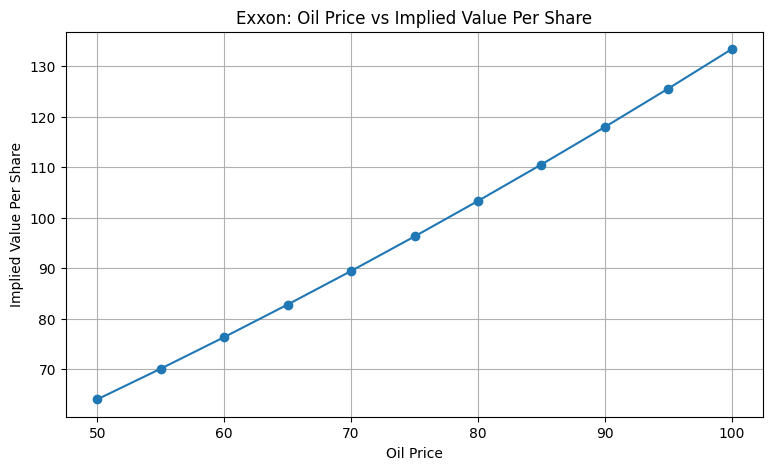

In [13]:
# CHART: OIL PRICE VS IMPLIED VALUE
# ============================================================

oil_range = list(range(50, 101, 5))
values = []

for oil in oil_range:
    adj_revenue, adj_margin = adjust_for_oil_price(oil, revenue_m, ebit_margin)
    fcf = project_fcf(
        revenue=adj_revenue,
        ebit_margin=adj_margin,
        depr_pct=depr_pct,
        capex_pct=capex_pct,
        nwc_pct=nwc_pct,
        years=forecast_years
    )

    _, val = dcf_valuation(
        fcf,
        wacc=wacc_base,
        terminal_growth=terminal_growth,
        net_debt=net_debt_m,
        shares_outstanding=shares_m
    )
    values.append(val["Implied Value per Share"])

plt.figure(figsize=(9, 5))
plt.plot(oil_range, values, marker="o")
plt.title("Exxon: Oil Price vs Implied Value Per Share")
plt.xlabel("Oil Price")
plt.ylabel("Implied Value Per Share")
plt.grid(True)
plt.show()
